In [ ]:
# import tensorflow as tf
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Housekeeping

In [ ]:
!pip install -q transformers
!pip install -q evaluate
!pip install -q datasets
!pip install -q requests
!pip install -q pandas
!pip install -q sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install -q biopython

In [ ]:
from Bio import SeqIO
import csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Preporcessing
Pick the preprocessed data to save time.

In [ ]:
#picking up the dataframe to avoid doing the same above step every time.
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/mydf.csv')

<ipython-input-6-46ec72bd8204>:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/mydf.csv')


In [ ]:
from collections import Counter

# Get counts of each class
class_counts = Counter(df['gene_type'])

class_reps = [(class_name, round(count / len(df) * 100, 4)) for class_name, count in class_counts.items()]
class_reps_sorted = sorted(class_reps, key=lambda x: x[1], reverse=True)

# Get class representation and sort in descending order
# Print representation of each class
for class_name, class_rep in class_reps_sorted:
    print(f"{class_name}: {class_rep}%")


protein_coding: 84.1407%
lncRNA: 13.1681%
processed_pseudogene: 0.7164%
unprocessed_pseudogene: 0.476%
transcribed_unprocessed_pseudogene: 0.3601%
transcribed_unitary_pseudogene: 0.3315%
transcribed_processed_pseudogene: 0.1786%
misc_RNA: 0.1346%
snRNA: 0.1157%
miRNA: 0.1143%
TEC: 0.0659%
snoRNA: 0.0573%
rRNA_pseudogene: 0.0302%
unitary_pseudogene: 0.0217%
IG_V_pseudogene: 0.0175%
IG_V_gene: 0.0175%
TR_V_gene: 0.0133%
artifact: 0.0066%
IG_C_gene: 0.006%
TR_J_gene: 0.0048%
TR_V_pseudogene: 0.0035%
scaRNA: 0.003%
rRNA: 0.0029%
translated_unprocessed_pseudogene: 0.0029%
IG_D_gene: 0.0023%
pseudogene: 0.0021%
TR_C_gene: 0.0014%
Mt_tRNA: 0.0013%
IG_J_gene: 0.0011%
IG_C_pseudogene: 0.0009%
ribozyme: 0.0005%
sRNA: 0.0003%
translated_processed_pseudogene: 0.0002%
TR_D_gene: 0.0002%
TR_J_pseudogene: 0.0002%
IG_J_pseudogene: 0.0002%
scRNA: 0.0001%
vault_RNA: 0.0001%
IG_pseudogene: 0.0001%
Mt_rRNA: 0.0001%


In [ ]:
  # Merge and rename the classes
df["gene_type"].replace({
    "processed_pseudogene": "pseudogene",
    "unprocessed_pseudogene": "pseudogene",
    "transcribed_unprocessed_pseudogene": "pseudogene",
    "transcribed_unitary_pseudogene": "pseudogene",
    "transcribed_processed_pseudogene": "pseudogene",
    "snRNA": "snRNA",
    "miRNA": "snRNA",
    "snoRNA": "snRNA"
}, inplace=True)

# Drop the underrepresented classes
df = df[df["gene_type"].isin(["protein_coding", "lncRNA", "pseudogene", "snRNA"])]

# Get the counts of each class
class_counts = df["gene_type"].value_counts()

# Print the counts
print(class_counts)


gene_type
protein_coding    1382631
lncRNA             216383
pseudogene          33925
snRNA                4722
Name: count, dtype: int64


In [ ]:
import pandas as pd
from collections import Counter

# Get counts of each class
class_counts = Counter(df['gene_type'])

# Calculate class representation and put it in a DataFrame
class_df = pd.DataFrame({'gene_type': list(class_counts.keys()),
                         'count': list(class_counts.values())})
class_df['percentage'] = round(class_df['count'] / len(df) * 100, 4)

# Sort the DataFrame in descending order of percentage
class_df = class_df.sort_values(by='percentage', ascending=False)

# Display the DataFrame
#print(class_df)
#class_df.to_excel('class_distribution.xlsx', index=False)

#from google.colab import files
#files.download('class_distribution.xlsx')

In [ ]:
#Representation of each class after merging
class_df

,gene_type,count,percentage
3,protein_coding,1382631,84.4272
0,lncRNA,216383,13.2129
1,pseudogene,33925,2.0716
2,snRNA,4722,0.2883


In [ ]:
# Checking number of classes we have
gene_types = set(df['gene_type'])
num_classes = len(gene_types)
print("Number of classes: ", num_classes)



Number of classes:  4


In [ ]:
def plot_sequence_length_distribution(sequence_leap, end, step):
  # Create ranges of 50,000 sequence lengths
  range_intervals = [(start, start + sequence_leap) for start in range(0, end, step)]

  # Initialize a list to store the counts for each range
  range_counts = [0] * len(range_intervals)

  # Iterate through the sequences and count the number of sequences in each range
  for seq_length in df['sequence'].apply(len):
      for i, (start, end) in enumerate(range_intervals):
          if start <= seq_length <= end:
              range_counts[i] += 1
              break

  # Create x-axis labels for the chart
  x_labels = [f"{start + 1}-{end}" for start, end in range_intervals]

  # Create the bar chart
  plt.bar(x_labels, range_counts)
  plt.xlabel('Sequence Length Range')
  plt.ylabel('Number of Sequences')
  plt.title('Distribution of Sequence Lengths')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()


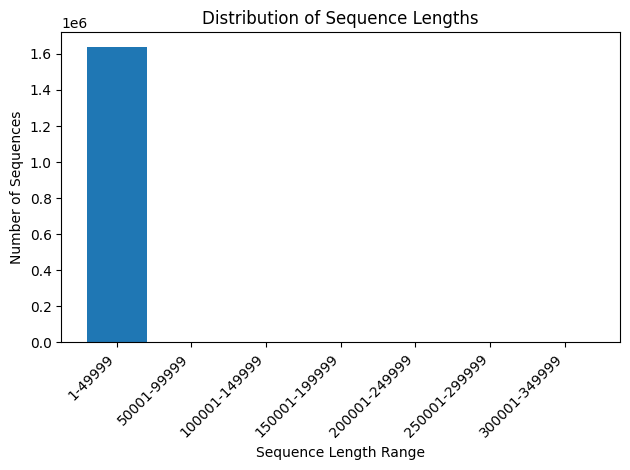

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plot_sequence_length_distribution(49999, 347300, 50000)

In [ ]:
import pandas as pd

# Create ranges
range_intervals = [(1, 50000), (50001, 100000), (100001, 150000), (150001, 200000),
                   (200001, 250000), (250001, 300000), (300001, 350000)]

# Initialize variables to store counts
range_counts = [0] * len(range_intervals)

# Iterate through the sequences and count sequences within each range
for seq_length in df['sequence'].apply(len):
    for i, (start, end) in enumerate(range_intervals):
        if start <= seq_length <= end:
            range_counts[i] += 1
            break

# Print the number of sequences in each range
for i, (start, end) in enumerate(range_intervals):
    print(f"{start}-{end}: {range_counts[i]}")


1-50000: 1637658
50001-100000: 1
100001-150000: 0
150001-200000: 0
200001-250000: 1
250001-300000: 0
300001-350000: 1


In [ ]:
import pandas as pd

def find_nlargestandnlargestseqs(df, nsmallseq, nlargeseq):

    #Calculate the lengths of sequences in the 'sequence' column and store them in the 'sequence_length' column
  df['sequence_length'] = df['sequence'].apply(len)

  # Convert 'sequence_length' column to numeric values
  df['sequence_length'] = pd.to_numeric(df['sequence_length'], errors='coerce')

  # Drop rows with missing or non-numeric values in the 'sequence_length' column
  df = df.dropna(subset=['sequence_length'])

  #find n samllest sequences
  smallest_sequences = df.nsmallest(nsmallseq, 'sequence_length')
  #find n largest sequences
  largest_sequences = df.nlargest(nlargeseq, 'sequence_length')

  print("Smallest sequences:")
  for index, row in smallest_sequences.iterrows():
      print(f"Gene Type: {row['gene_type']}, Sequence Length: {row['sequence_length']}")

  print("\nLargest sequences:")
  for index, row in largest_sequences.iterrows():
      print(f"Gene Type: {row['gene_type']}, Sequence Length: {row['sequence_length']}")

In [ ]:
find_nlargestandnlargestseqs(df, 20, 20)

Smallest sequences:
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1
Gene Type: protein_coding, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 1

Largest sequences:
Gene Type: lncRNA, Sequence Length: 347300
Gene Type: lncRNA, Sequence Length: 205012
Gene Type: lncRNA, Sequence Length: 91667
Gene Type: lncRNA, Seque

In [ ]:
import pandas as pd



# Calculate the lengths of sequences in the 'sequence' column and store them in the 'sequence_length' column
df['sequence_length'] = df['sequence'].apply(len)

# Convert 'sequence_length' column to numeric values
df['sequence_length'] = pd.to_numeric(df['sequence_length'], errors='coerce')

# Drop rows with missing or non-numeric values in the 'sequence_length' column
df = df.dropna(subset=['sequence_length'])

# Keep only the sequences within the range of 1 to 20000
df = df[(df['sequence_length'] >= 1) & (df['sequence_length'] <= 20000)]

df.head()


,chrom,start,end,gene_type,sequence,sequence_length
0,1,11869,12227,lncRNA,GTTAACTTGCCGTCAGCCTTTTCTTTGACCTCTTCTTTCTGTTCAT...,359
1,1,12613,12721,lncRNA,GTGTGTGGTGATGCCAGGCATGCCCTTCCCCAGCATCAGGTCTCCA...,109
2,1,13221,14409,lncRNA,GCAGGGCCATCAGGCACCAAAGGGATTCTGCCAGCATAGTGCTCCT...,1189
3,1,12010,12057,pseudogene,GTGTCTGACTTCCAGCAACTGCTGGCCTGTGCCAGGGTGCAAGCTGAG,48
4,1,12179,12227,pseudogene,TTGGAGGAAAGATGAGTGAGAGCATCAACTTCTCTCACAACCTAGGCCA,49


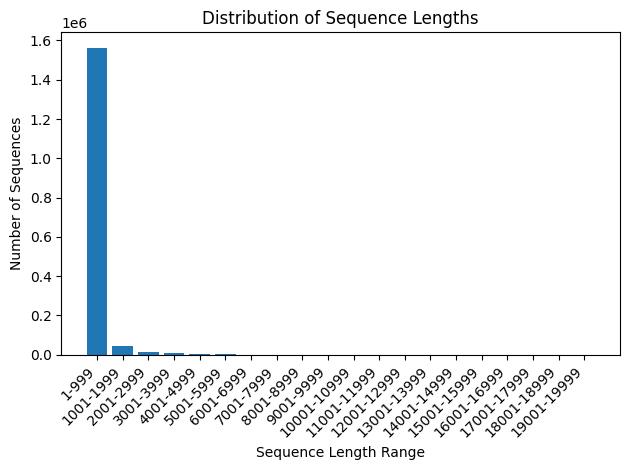

In [ ]:
plot_sequence_length_distribution(999, 20000, 1000)

In [ ]:
import pandas as pd



# Create a list to store the results for each chunk
chunk_results = []

# Define the chunk size
chunk_size = 100

# Loop through chunks from 1 to 4000
for start in range(1, 4000, chunk_size):
    end = min(start + chunk_size, 4001)  # Make sure we don't exceed the upper limit

    # Filter the DataFrame for the current chunk
    chunk_df = df[(df['sequence_length'] >= start) & (df['sequence_length'] < end)]

    # Calculate the representation of each class in the current chunk
    class_counts = chunk_df['gene_type'].value_counts().to_dict()

    # Append the results to the list
    chunk_results.append({
        'Chunk_Start': start,
        'Chunk_End': end,
        **class_counts  # Include class counts in the result
    })

# Create a DataFrame from the results
chunk_results_df = pd.DataFrame(chunk_results)

# Fill missing values with zeros
chunk_results_df.fillna(0, inplace=True)

# Set index to Chunk_Start and Chunk_End
chunk_results_df.set_index(['Chunk_Start', 'Chunk_End'], inplace=True)

# Print the table-like representation of class counts
print(chunk_results_df)


                       protein_coding  lncRNA  pseudogene   snRNA
Chunk_Start Chunk_End                                            
1           101                458221   59125        6956  2425.0
101         201                619437   75103       10565  2218.0
201         301                129726   26665        4103    72.0
301         401                 42606   13621        2603     2.0
401         501                 26013    8356        2000     0.0
501         601                 16899    5672        1395     1.0
601         701                 11580    4152        1007     1.0
701         801                  8890    3147         911     3.0
801         901                  7118    2541         753     0.0
901         1001                 6106    2159         913     0.0
1001        1101                 5050    1689         434     0.0
1101        1201                 4124    1430         364     0.0
1201        1301                 3815    1343         406     0.0
1301      

In [ ]:
import pandas as pd

# Assuming you have a DataFrame named df with columns 'sequence_length' and 'sequence'

# Filter sequences with lengths between 1 and 300
filtered_df = df[(df['sequence_length'] >= 1) & (df['sequence_length'] <= 300)]



In [ ]:
df = filtered_df

In [ ]:
# Assuming you have a DataFrame named df with columns 'sequence_length', 'sequence', and 'gene_type'

# Create an empty DataFrame to store the selected sequences
selected_df = pd.DataFrame(columns=['sequence_length', 'sequence', 'gene_type'])

# Define the number of sequences to select for each class
sequences_per_class = 2000

# Iterate through unique classes in 'gene_type'
unique_classes = df['gene_type'].unique()
for gene_type in unique_classes:
    # Filter sequences for the current class and range
    filtered_sequences = df[(df['gene_type'] == gene_type) & (df['sequence_length'] >= 1) & (df['sequence_length'] <= 100)]
    # Take the first 2000 sequences for this class and range
    selected_df = pd.concat([selected_df, filtered_sequences.head(sequences_per_class)])
# Now, selected_df contains 8000 sequences, 2000 from each class, in the range 1 to 100.


In [ ]:
# Define the range for the second task
start_range = 101
end_range = 200

# Iterate through unique classes in 'gene_type' (assuming the same classes as before)
for gene_type in unique_classes:
    # Filter sequences for the current class and range
    filtered_sequences = df[(df['gene_type'] == gene_type) & (df['sequence_length'] >= start_range) & (df['sequence_length'] <= end_range)]
    # Take the first 2000 sequences for this class and range
    # Use pandas.concat to append filtered_sequences to selected_df
    selected_df = pd.concat([selected_df, filtered_sequences.head(sequences_per_class)], ignore_index=True)

# Now, selected_df contains 8000 sequences, 2000 from each class, in the range 101 to 200.


In [ ]:
# Define the range for the third task
start_range = 201
end_range = 300

# Define the number of sequences to select for each class
sequences_per_class = 70

# Iterate through unique classes in 'gene_type' (assuming the same classes as before)
for gene_type in unique_classes:
    # Filter sequences for the current class and range
    filtered_sequences = df[(df['gene_type'] == gene_type) & (df['sequence_length'] >= start_range) & (df['sequence_length'] <= end_range)]
    # Take the first 70 sequences for this class and range
    selected_df = pd.concat([selected_df, filtered_sequences.head(sequences_per_class)], ignore_index=True)

# Now, selected_df contains 280 sequences, 70 from each class, in the range 201 to 300.


In [ ]:
df = selected_df

In [ ]:
# import pandas as pd

# # Load your DataFrame here
# # df = pd.read_csv('your_data.csv')

# # Calculate the lengths of sequences in the 'sequence' column and store them in the 'sequence_length' column
# df['sequence_length'] = df['sequence'].apply(len)

# # Convert 'sequence_length' column to numeric values
# df['sequence_length'] = pd.to_numeric(df['sequence_length'], errors='coerce')

# # Drop rows with missing or non-numeric values in the 'sequence_length' column
# df = df.dropna(subset=['sequence_length'])

# # Keep only the sequences within the range of specific length
# df = df[(df['sequence_length'] >= 50) & (df['sequence_length'] <= 1000)]



In [ ]:
find_nlargestandnlargestseqs(df,5,5)

Smallest sequences:
Gene Type: lncRNA, Sequence Length: 1
Gene Type: lncRNA, Sequence Length: 3
Gene Type: pseudogene, Sequence Length: 3
Gene Type: pseudogene, Sequence Length: 3
Gene Type: pseudogene, Sequence Length: 4

Largest sequences:
Gene Type: pseudogene, Sequence Length: 299
Gene Type: pseudogene, Sequence Length: 299
Gene Type: lncRNA, Sequence Length: 298
Gene Type: lncRNA, Sequence Length: 297
Gene Type: lncRNA, Sequence Length: 297


In [ ]:
df.shape

(16280, 6)

In [ ]:
gene_type_counts = df['gene_type'].value_counts()

print("Gene Type Counts:")
print(gene_type_counts)

Gene Type Counts:
gene_type
lncRNA            4070
pseudogene        4070
snRNA             4070
protein_coding    4070
Name: count, dtype: int64


In [ ]:
gene_type_counts = df['gene_type'].value_counts()

print("Gene Type Counts:")
print(gene_type_counts)

Gene Type Counts:
gene_type
lncRNA            4070
pseudogene        4070
snRNA             4070
protein_coding    4070
Name: count, dtype: int64


In [ ]:
# take smaller dataframe for testing purposes as the whole dataframe will crash the colab.
#df = df.sample(n=200000, random_state=42)


In [ ]:
class_mapping = {
    'protein_coding': 0,
    'lncRNA': 1,
    'pseudogene': 2,
    'snRNA': 3
}
df['label'] = df['gene_type'].map(class_mapping)


In [ ]:
# #test
# lnc_df['lable'] = lnc_df['type'].map(class_mapping)

In [ ]:
df.head()

,sequence_length,sequence,gene_type,chrom,start,end,label
0,56,AGCTATCTGAATTTCTCCTTCTCCTAAAAATGCACATCCTATGACT...,lncRNA,1,57598.0,57653.0,1
1,11,ATTGGTTTGGT,lncRNA,1,92230.0,92240.0,1
2,59,TTCTTCATTGAATCCTGGATGCTTTATTTTTCTTAATAAGAGGAAT...,lncRNA,1,120874.0,120932.0,1
3,58,CATAATGTAGAATCAGTGGGCGTGTTAAGCTTGTTTTCCTGCAACT...,lncRNA,1,139790.0,139847.0,1
4,66,CATATTTTCTTTCAGACAATTCTTCAGTTTGTTTACGTAGATCAGC...,lncRNA,1,168100.0,168165.0,1


In [ ]:
from sklearn.model_selection import train_test_split

train_sequences, test_sequences, train_labels, test_labels = train_test_split(df['sequence'], df['label'], test_size=0.25, shuffle=True)

In [ ]:
train_sequences=train_sequences.tolist()
test_sequences=test_sequences.tolist()
train_labels=train_labels.tolist()
test_labels=test_labels.tolist()

In [ ]:
# #test
# lnc_df_sequence = lnc_df['sequence_x'].tolist()
# lnc_df_label = lnc_df['lable'].tolist()

In [ ]:
# #test
# lnc_df_label[1]

In [ ]:
train_labels[1]

3

In [ ]:
model_checkpoint = 'facebook/esm2_t12_35M_UR50D'

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
train_tokenized = tokenizer(train_sequences, max_length=300, truncation=True, padding=True)
test_tokenized = tokenizer(test_sequences, max_length=300, truncation=True, padding=True)

In [ ]:
# #test
# train_tokenizedtest = tokenizer(lnc_df_sequence, max_length=300, truncation=True, padding=True)


In [ ]:
from datasets import Dataset
train_dataset = Dataset.from_dict(train_tokenized)
test_dataset = Dataset.from_dict(test_tokenized)

train_dataset

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 12210
})

In [ ]:
# #test
# test_dataset_test = Dataset.from_dict(train_tokenizedtest)

In [ ]:
train_dataset = train_dataset.add_column("labels", train_labels)
test_dataset = test_dataset.add_column("labels", test_labels)
train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 12210
})

In [ ]:
# #test
# test_dataset_test = test_dataset_test.add_column("labels", lnc_df_label)
# test_dataset_test

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

num_labels = 4
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)

Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
! pip install -q -U accelerate
! pip install -q -U transformers

In [ ]:
df.shape

(16280, 7)

# test start

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model_checkpoint = 'facebook/esm2_t6_8M_UR50D'
model_name = "esm2"  # Replace with your model name
batch_size = 16  # Replace with your preferred batch size

args = TrainingArguments(
    output_dir=f"{model_name}-finetuned-localization",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir='./logs',  # Directory for storing logs
    logging_steps=10,  # Log every 10 steps
    push_to_hub=False,
)

# Load metrics
from evaluate import load
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Create the Trainer object
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],  # Optional: early stopping
)

# Train the model
trainer.train()


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.868000,0.916076,0.619656,0.604096,0.619656,0.585736
2,0.681400,0.719442,0.708354,0.734576,0.708354,0.704545
3,0.417200,0.594098,0.775676,0.771762,0.775676,0.772910
4,0.358800,0.698469,0.773219,0.794668,0.773219,0.777084
5,0.107500,0.811912,0.795086,0.794427,0.795086,0.792556
6,0.130700,0.921254,0.810319,0.811242,0.810319,0.810592
7,0.082200,0.995445,0.806388,0.814047,0.806388,0.808302
8,0.025100,1.058072,0.803686,0.818699,0.803686,0.806227
9,0.003500,1.010046,0.807125,0.809685,0.807125,0.808025


TrainOutput(global_step=6876, training_loss=0.3176759476308863, metrics={'train_runtime': 4114.2579, 'train_samples_per_second': 29.677, 'train_steps_per_second': 1.857, 'total_flos': 6623693705970000.0, 'train_loss': 0.3176759476308863, 'epoch': 9.0})

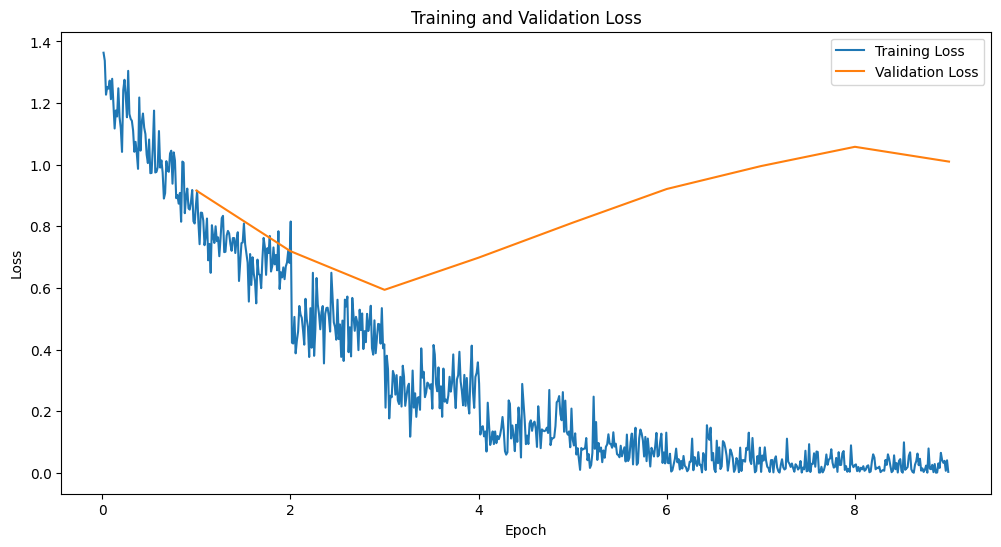

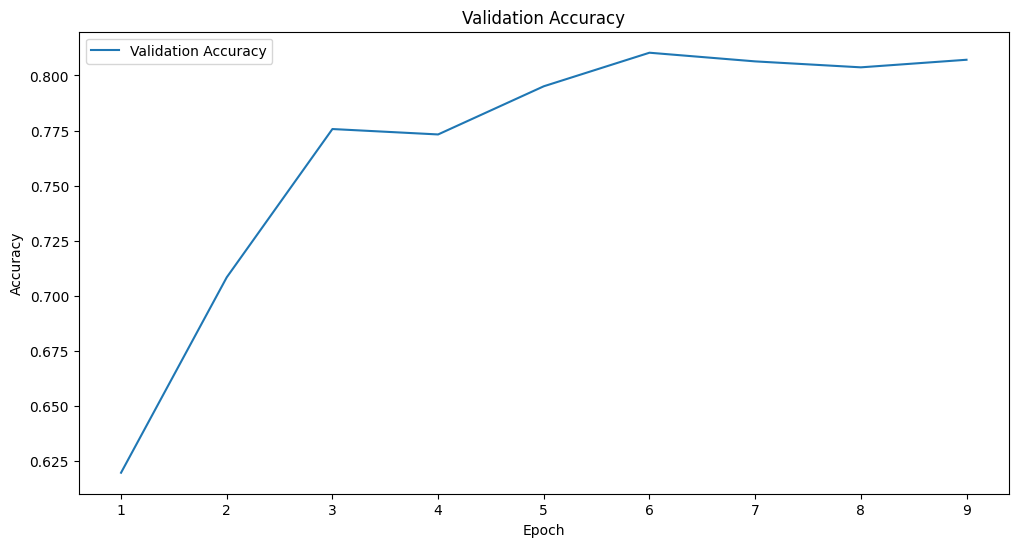

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import TrainerCallback, TrainerState, TrainerControl

# Read the log file
log_history = trainer.state.log_history

# Convert the log history to a DataFrame
df = pd.DataFrame(log_history)

# Filter out the entries for training and evaluation
train_df = df[df['epoch'].notna() & df['loss'].notna()]
eval_df = df[df['eval_loss'].notna()]

# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(train_df['epoch'], train_df['loss'], label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot the training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(eval_df['epoch'], eval_df['eval_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()


# test end

# Preparing Model


In [ ]:
from transformers import TrainingArguments

# Adjust these parameters
model_name = "esm2"  # Replace with your model name
batch_size = 16  # Replace with your preferred batch size

args = TrainingArguments(
    f"{model_name}-finetuned-localization",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",  # Change metric to F1-score
    push_to_hub=True,
)


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from evaluate import load
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metric = load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# Model Training

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
# Create the Trainer object
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.091300,0.812854,0.654054,0.676970,0.654054,0.622201
2,0.646100,0.647889,0.746192,0.765342,0.746192,0.746505
3,0.439300,0.570831,0.790172,0.785907,0.790172,0.786926
4,0.240600,0.648920,0.801229,0.799492,0.801229,0.799949
5,0.132600,0.869139,0.802457,0.802324,0.802457,0.801794
6,0.077200,0.908999,0.814496,0.815016,0.814496,0.814304
7,0.047500,0.991375,0.810565,0.812724,0.810565,0.810469
8,0.029700,0.934063,0.823342,0.826935,0.823342,0.823903
9,0.026400,0.973105,0.819410,0.821981,0.819410,0.819806
10,0.021100,0.981569,0.818919,0.820363,0.818919,0.819011


TrainOutput(global_step=7640, training_loss=0.2669476654517089, metrics={'train_runtime': 4431.1437, 'train_samples_per_second': 27.555, 'train_steps_per_second': 1.724, 'total_flos': 7359659673300000.0, 'train_loss': 0.2669476654517089, 'epoch': 10.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.9340627789497375,
 'eval_accuracy': 0.8233415233415233,
 'eval_precision': 0.8269346742138808,
 'eval_recall': 0.8233415233415233,
 'eval_f1': 0.8239027661555933,
 'eval_runtime': 49.1645,
 'eval_samples_per_second': 82.783,
 'eval_steps_per_second': 5.187}

In [ ]:
# Save the trained model
model.save_pretrained('/content/drive/My Drive/my_transformer')

In [ ]:
# Load the saved model
loaded_model = AutoModelForSequenceClassification.from_pretrained('/content/drive/My Drive/my_transformer')


In [ ]:
# Step 1: Parse GTF file and extract relevant information
gtf_file = open('/content/drive/MyDrive/LncExpDB_OnlyLnc.gtf', 'r')
# Create a dictionary to map chromosome names
chrom_mapping = {
    'chr1': '1',
    'chr2': '2',
    'chr3': '3',
    'chr4': '4',
    'chr5': '5',
    'chr6': '6',
    'chr7': '7',
}
data = []
reader = csv.reader(gtf_file, delimiter='\t')
for i in range(5):
  next(reader)
# Loop through GTF file and replace chromosome names
for row in reader:
    # Get chromosome name
    chrom = row[0]
    # Check if chromosome name needs to be mapped
    if chrom in chrom_mapping:
        # Map chromosome name
        chrom = chrom_mapping[chrom]
        # Update row with mapped chromosome name
        row[0] = chrom

    if row[2] == 'exon':
      chrom = row[0]
      start = int(row[3])
      end = int(row[4])
      data.append({'chrom': chrom, 'start': start, 'end': end})


In [ ]:
len(data)

179618

In [ ]:
from Bio import SeqIO

fasta_file_path = '/content/drive/My Drive/Homo_sapiens.GRCh38.dna.primary_assembly.fa'
# Using Biopython's SeqIO to efficiently read the fasta file and create the sequence dictionary
seq_dict = {}
for record in SeqIO.parse(fasta_file_path, 'fasta'):
    seq_dict[record.id] = str(record.seq)

In [ ]:
len(seq_dict)

194

In [ ]:
# Step 3: Combine information from GTF and FASTA files
for record in data:
  chrom = record['chrom']
  start = record['start']
  end = record['end']
  seq = seq_dict[chrom][start-1:end]
  record['sequence'] = seq

In [ ]:
import pandas as pd

Lnc_df_combined = pd.DataFrame.from_dict(data)

In [ ]:
Lnc_df_combined.head()

,chrom,start,end,sequence
0,1,16035,16310,GAGGGAAGTCACCTCCCCTCAAACGAGGAGCCCTGCGCTGGGGAGG...
1,1,16607,16668,CTGAAGGAGACGCGCTGCTGCTGCTGTCGTCCTGCCTGGCGCCTTG...
2,1,15603,16765,GAGCCATAGCCCAGGCAGGAGGGCTGAGGACCTCTGGTGGCGGCCC...
3,1,29321,29370,CTGCGAGCCGCCCTCCCGGAAGCTCCCGCCGCCGCTTCCGCTCTGC...
4,1,15603,16765,GAGCCATAGCCCAGGCAGGAGGGCTGAGGACCTCTGGTGGCGGCCC...


In [ ]:
len(Lnc_df_combined)

179618

In [ ]:
Lnc_df_combined_no_duplicates = Lnc_df_combined.drop_duplicates()
len(Lnc_df_combined_no_duplicates)

109668

In [ ]:
len(df)

16280

In [ ]:

lncRNA_df = df[df['gene_type'] == 'lncRNA']

# Print or use lncRNA_df as per your requirement
lncRNA_df.head()

,sequence_length,sequence,gene_type,chrom,start,end,label
0,56,AGCTATCTGAATTTCTCCTTCTCCTAAAAATGCACATCCTATGACT...,lncRNA,1,57598.0,57653.0,1
1,11,ATTGGTTTGGT,lncRNA,1,92230.0,92240.0,1
2,59,TTCTTCATTGAATCCTGGATGCTTTATTTTTCTTAATAAGAGGAAT...,lncRNA,1,120874.0,120932.0,1
3,58,CATAATGTAGAATCAGTGGGCGTGTTAAGCTTGTTTTCCTGCAACT...,lncRNA,1,139790.0,139847.0,1
4,66,CATATTTTCTTTCAGACAATTCTTCAGTTTGTTTACGTAGATCAGC...,lncRNA,1,168100.0,168165.0,1


In [ ]:
len(lncRNA_df)

4070

In [ ]:
len(Lnc_df_combined_no_duplicates)

109668

In [ ]:
  merged_df = pd.merge(Lnc_df_combined_no_duplicates, lncRNA_df, on=['start', 'end'], how='left', indicator=True)

  # Select rows only present in Lnc_df_combined
  result_df = merged_df[merged_df['_merge'] == 'left_only']

  # Drop the indicator column
  result_df.drop(columns='_merge', inplace=True)

  # Now result_df contains Lnc_df_combined with rows removed where start and end match with lncRNA_df
  len(result_df)

<ipython-input-73-0de2ff417941>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df.drop(columns='_merge', inplace=True)


107901

In [ ]:
len(result_df)

107901

In [ ]:
result_df.head()

,chrom_x,start,end,sequence_x,sequence_length,sequence_y,gene_type,chrom_y,label
0,1,16035,16310,GAGGGAAGTCACCTCCCCTCAAACGAGGAGCCCTGCGCTGGGGAGG...,NaN,NaN,NaN,NaN,NaN
1,1,16607,16668,CTGAAGGAGACGCGCTGCTGCTGCTGTCGTCCTGCCTGGCGCCTTG...,NaN,NaN,NaN,NaN,NaN
2,1,15603,16765,GAGCCATAGCCCAGGCAGGAGGGCTGAGGACCTCTGGTGGCGGCCC...,NaN,NaN,NaN,NaN,NaN
3,1,29321,29370,CTGCGAGCCGCCCTCCCGGAAGCTCCCGCCGCCGCTTCCGCTCTGC...,NaN,NaN,NaN,NaN,NaN
4,1,18497,18554,CTACTTGCCAGGGCCGATCTTGGTGCCATCCAGGGGGCCTCTACAA...,NaN,NaN,NaN,NaN,NaN


In [ ]:
result_df_sequence_only = result_df[['sequence_x']].copy()

# Add a new column named 'type' with the value 'lncRNA'
result_df_sequence_only['type'] = 'lncRNA'

# Print the resulting DataFrame
result_df_sequence_only.head()

,sequence_x,type
0,GAGGGAAGTCACCTCCCCTCAAACGAGGAGCCCTGCGCTGGGGAGG...,lncRNA
1,CTGAAGGAGACGCGCTGCTGCTGCTGTCGTCCTGCCTGGCGCCTTG...,lncRNA
2,GAGCCATAGCCCAGGCAGGAGGGCTGAGGACCTCTGGTGGCGGCCC...,lncRNA
3,CTGCGAGCCGCCCTCCCGGAAGCTCCCGCCGCCGCTTCCGCTCTGC...,lncRNA
4,CTACTTGCCAGGGCCGATCTTGGTGCCATCCAGGGGGCCTCTACAA...,lncRNA


In [ ]:
len(result_df_sequence_only)

107901

In [ ]:
lnc_df_path = '/content/drive/MyDrive/result_lncdf_sequence_filtered.xlsx'
lnc_df = pd.read_excel(lnc_df_path)

In [ ]:
len(lnc_df)

59631

In [ ]:
# Import pandas
import pandas as pd

# Assume lnc_df is already defined

# Filter the DataFrame
filtered_lnc_df = lnc_df[lnc_df['sequence_x'].apply(len) <= 300]


In [ ]:
len(filtered_lnc_df)

59631

In [ ]:
lnc_df.head()

,sequence_x,type,sequence_encoded
0,GAGGGAAGTCACCTCCCCTCAAACGAGGAGCCCTGCGCTGGGGAGG...,lncRNA,GAGGGAAGTCACCTCCCCTCAAACGAGGAGCCCTGCGCTGGGGAGG...
1,CTGAAGGAGACGCGCTGCTGCTGCTGTCGTCCTGCCTGGCGCCTTG...,lncRNA,CTGAAGGAGACGCGCTGCTGCTGCTGTCGTCCTGCCTGGCGCCTTG...
2,CTGCGAGCCGCCCTCCCGGAAGCTCCCGCCGCCGCTTCCGCTCTGC...,lncRNA,CTGCGAGCCGCCCTCCCGGAAGCTCCCGCCGCCGCTTCCGCTCTGC...
3,CTACTTGCCAGGGCCGATCTTGGTGCCATCCAGGGGGCCTCTACAA...,lncRNA,CTACTTGCCAGGGCCGATCTTGGTGCCATCCAGGGGGCCTCTACAA...
4,CTTGAGAGGCTCGGCTACCTCAGTGTGGAAGGTGGGCAGTTCTGGA...,lncRNA,CTTGAGAGGCTCGGCTACCTCAGTGTGGAAGGTGGGCAGTTCTGGA...
